# Dice Detection Dataset Inspector

Load and visualize dice detection images with bounding boxes from the dataset using an iterator.

## 1. Import Required Libraries

In [1]:
import sys
sys.path.insert(0, '/workspace/ai')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from src.dataset import S7DatasetDiceDetection, get_image_detection_datas
from src.config.config import load_config

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Configuration

In [2]:
config = load_config('config/config.yml')
print(f"✓ Configuration loaded")
print(f"  Dataset path: {config.dataset_path}")
print(f"  Image resolution: {config.tasks.dice_detection.image_resolution}")
print(f"  Colored: {config.colored}")

✓ Configuration loaded
  Dataset path: ../datasets/s7dataset-2-dice-detection
  Image resolution: (640, 480)
  Colored: False


## 3. Load Detection Dataset

In [3]:
print("Loading detection dataset...")
# Get all image detection data
image_datas = get_image_detection_datas(
    dataset_path=config.dataset_path,
    num_workers=4
)
print(f"✓ Total images found: {len(image_datas)}")

# Create dataset instance
dataset = S7DatasetDiceDetection(
    image_datas=image_datas,
    image_resolution=config.tasks.dice_detection.image_resolution,
    cache_path="output/dice-detection-train",
    colored=config.colored,
    use_random=True,
    dataset_repeat=1,
)

print("✓ Dataset created successfully!")

Loading detection dataset...
✓ Total images found: 693
✓ Dataset created successfully!


## 4. Create Dataset Iterator

In [4]:
# Create an iterator from the dataset
dataset_iterator = iter(dataset.generate_data())

print("✓ Iterator created successfully!")
print("Use next(dataset_iterator) to get the next image-bbox pair")

✓ Iterator created successfully!
Use next(dataset_iterator) to get the next image-bbox pair


## 5. Visualize Single Image with Bounding Boxes

Run this cell multiple times to see different images from the dataset

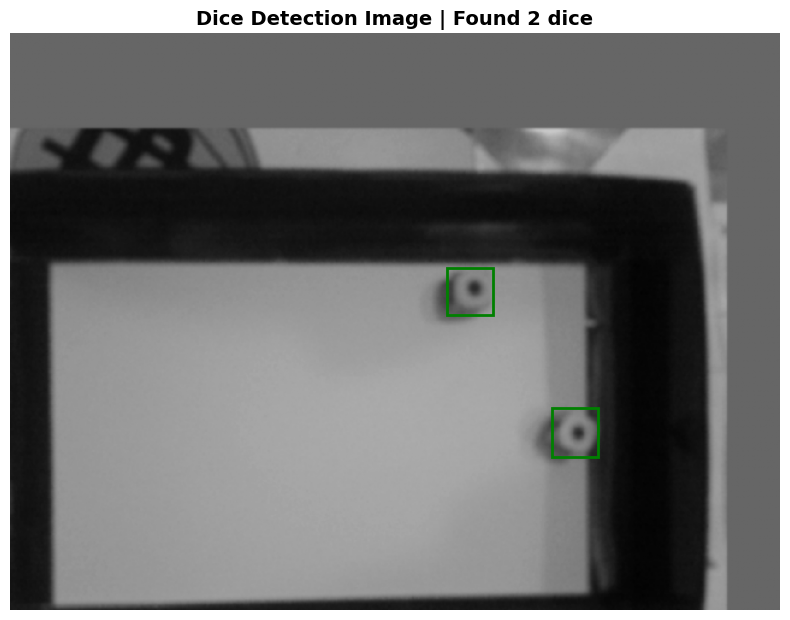

Image shape: (480, 640, 1)
Number of bounding boxes: 2
Bounding boxes: [(363, 195, 38, 39), (450, 312, 38, 40)]
Image dtype: uint8
Image min: 2, max: 201


In [5]:
# Get next image and bboxes from iterator
img, bboxes = next(dataset_iterator)

# Create figure and display the image
fig, ax = plt.subplots(figsize=(8, 8))

# Display the image (handle both grayscale and color)
if len(img.shape) == 2:
    # Grayscale image
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
elif img.shape[2] == 1:
    # Single channel image
    ax.imshow(img[:,:,0], cmap='gray', vmin=0, vmax=255)
else:
    # Color image
    ax.imshow(img.astype(np.uint8), vmin=0, vmax=255)

# Draw bounding boxes
for i, bbox in enumerate(bboxes):
    x, y, w, h = bbox
    rect = Rectangle(
        (x, y),
        w, h,
        linewidth=2,
        edgecolor="green",
        facecolor="none",
        label="Dice" if i == 0 else ""
    )
    ax.add_patch(rect)

ax.set_title(f'Dice Detection Image | Found {len(bboxes)} dice', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {img.shape}")
print(f"Number of bounding boxes: {len(bboxes)}")
print(f"Bounding boxes: {bboxes}")
print(f"Image dtype: {img.dtype}")
print(f"Image min: {img.min()}, max: {img.max()}")

## 6. Visualize Grid of Images with Bounding Boxes

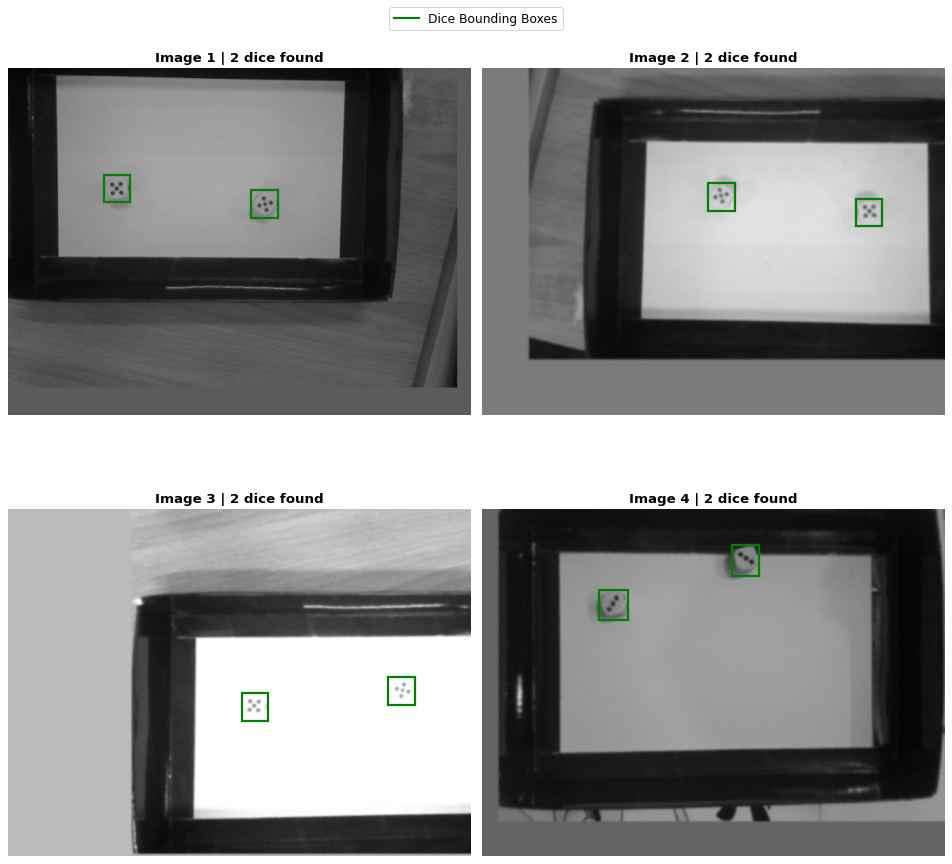

In [24]:
# Determine number of images to display
num_viz_images = 4

# Create figure
rows = 2
cols = 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 12), dpi=80)
axes = axes.flatten()

for i in range(num_viz_images):
    ax = axes[i]

    # Get next image and bboxes from generator
    img, bboxes = next(dataset_iterator)
    
    # Display image
    if len(img.shape) == 2:
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    elif img.shape[2] == 1:
        ax.imshow(img[:,:,0], cmap='gray', vmin=0, vmax=255)
    else:
        ax.imshow(img.astype(np.uint8), vmin=0, vmax=255)

    # Draw ground truth bounding boxes
    for bbox in bboxes:
        x, y, w, h = bbox
        rect = Rectangle(
            (x, y),
            w, h,
            linewidth=2,
            edgecolor="green",
            facecolor="none",
        )
        ax.add_patch(rect)

    ax.set_title(f'Image {i+1} | {len(bboxes)} dice found', fontsize=12, fontweight='bold')
    ax.axis('off')

# Hide unused subplots
for i in range(num_viz_images, rows * cols):
    axes[i].axis('off')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', linewidth=2, label='Dice Bounding Boxes')
]
fig.legend(handles=legend_elements, loc='upper center', 
          bbox_to_anchor=(0.5, 0.98), ncol=1, fontsize=11)

plt.tight_layout()
plt.show()